# Song2Vec: Building a Music Recommender System with Word Embeddings


Below I implemented a Song2Vec music recommendation system using Word2Vec embeddings trained on the 30Music playlist dataset. Songs co-occurring in user-created playlists are treated as "words in sentences," allowing the model to learn semantic similarity between tracks and place them in a vector space.

**Pipeline:** Playlist data → Track sequences → Word2Vec training → Embedding-based recommendation & evaluation

**Random seed:** 42 

In [1]:
# Cell 1: Imports & Setup
import json
import random
import numpy as np
import pandas as pd
import gensim
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from urllib.parse import unquote_plus
from tqdm import tqdm
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("All imports successful!")


All imports successful!


In [2]:
# Cell 2: Parse tracks.idomaar → track_id to "artist__title" mapping

track_id_to_name = {}
with open("data/tracks.idomaar", "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Parsing tracks"):
        parts = line.strip().split("\t")
        if len(parts) < 4:
            continue
        track_id = parts[1]
        try:
            metadata = json.loads(parts[3])
            raw_name = metadata.get("name", "")
            # URL decode: + → space, %XX → special chars
            decoded = unquote_plus(raw_name)
            # Split on /_/ to get artist and title
            if "/_/" in decoded:
                artist, title = decoded.split("/_/", 1)
            else:
                continue  # skip tracks without proper format
            # Normalize: lowercase, strip whitespace
            artist = artist.strip().lower()
            title = title.strip().lower()
            track_name = f"{artist}__{title}"
            track_id_to_name[track_id] = track_name
        except (json.JSONDecodeError, ValueError):
            continue

print(f"Total tracks parsed: {len(track_id_to_name):,}")
# Show a few examples
for i, (tid, tname) in enumerate(list(track_id_to_name.items())[:5]):
    print(f"  ID {tid} → {tname}")

Parsing tracks: 5675143it [00:16, 351008.04it/s]


Total tracks parsed: 4,519,105
  ID 0 → 000003 music instructor__dj's rock da house â≈æ≈ê01 - dj max-pulemet vs. bomfunk mc's - electro breakdance party 1 [2000] = cd oneâ≈æ≈ê
  ID 1 → 00-01__текст
  ID 2 → 0005. overkill__overkill
  ID 3 → 000c tony dize__ruleta rusa
  ID 4 → 000 oscarcito__tumbay‚ (lyrics)


In [3]:
# Cell 3: Parse playlist.idomaar → list of playlists (each playlist = list of track names)

playlists = []
skipped_playlists = 0

with open("data/playlist.idomaar", "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Parsing playlists"):
        parts = line.strip().split("\t")
        if len(parts) < 5:
            skipped_playlists += 1
            continue
        try:
            subjects_objects = json.loads(parts[4])
            # Extract track IDs from objects (some entries are lists, not dicts)
            track_ids = []
            for obj in subjects_objects.get("objects", []):
                if isinstance(obj, dict) and obj.get("type") == "track":
                    track_ids.append(str(obj["id"]))
            
            # Convert track IDs to track names
            track_names = [
                track_id_to_name[tid] 
                for tid in track_ids 
                if tid in track_id_to_name
            ]
            # Only keep playlists with at least 2 songs
            if len(track_names) >= 2:
                playlists.append(track_names)
        except (json.JSONDecodeError, KeyError):
            skipped_playlists += 1
            continue

print(f"Total valid playlists: {len(playlists):,}")
print(f"Skipped playlists: {skipped_playlists:,}")
print(f"\nExample playlist (first 5 songs):")
print(f"  Length: {len(playlists[0])} songs")
for s in playlists[0][:5]:
    print(f"    • {s}")

Parsing playlists: 57561it [00:01, 41019.87it/s]

Total valid playlists: 47,130
Skipped playlists: 0

Example playlist (first 5 songs):
  Length: 27 songs
    • the whip__trash (crookers remix)
    • modeselektor__sucker pin
    • simian mobile disco__hustler
    • gossip__standing in the way of control
    • kalwi & remi__explosion (dj theo remix)


# Exploratory Data Analysis

I analyzied playlist length distribution, track frequency, top-K tracks/artists, and vocabulary statistics to understand the dataset characteristics before model training.

In [4]:
# Cell 4: Train/Test Split (80/20 at playlist level)
from sklearn.model_selection import train_test_split

train_playlists, test_playlists = train_test_split(playlists, test_size=0.2, random_state=SEED)

print(f"Train playlists: {len(train_playlists):,}")
print(f"Test playlists:  {len(test_playlists):,}")

# Basic stats
train_lengths = [len(p) for p in train_playlists]
test_lengths = [len(p) for p in test_playlists]
print(f"\nTrain - avg playlist length: {np.mean(train_lengths):.1f}, median: {np.median(train_lengths):.1f}")
print(f"Test  - avg playlist length: {np.mean(test_lengths):.1f}, median: {np.median(test_lengths):.1f}")

Train playlists: 37,704
Test playlists:  9,426

Train - avg playlist length: 34.1, median: 15.0
Test  - avg playlist length: 33.6, median: 15.0


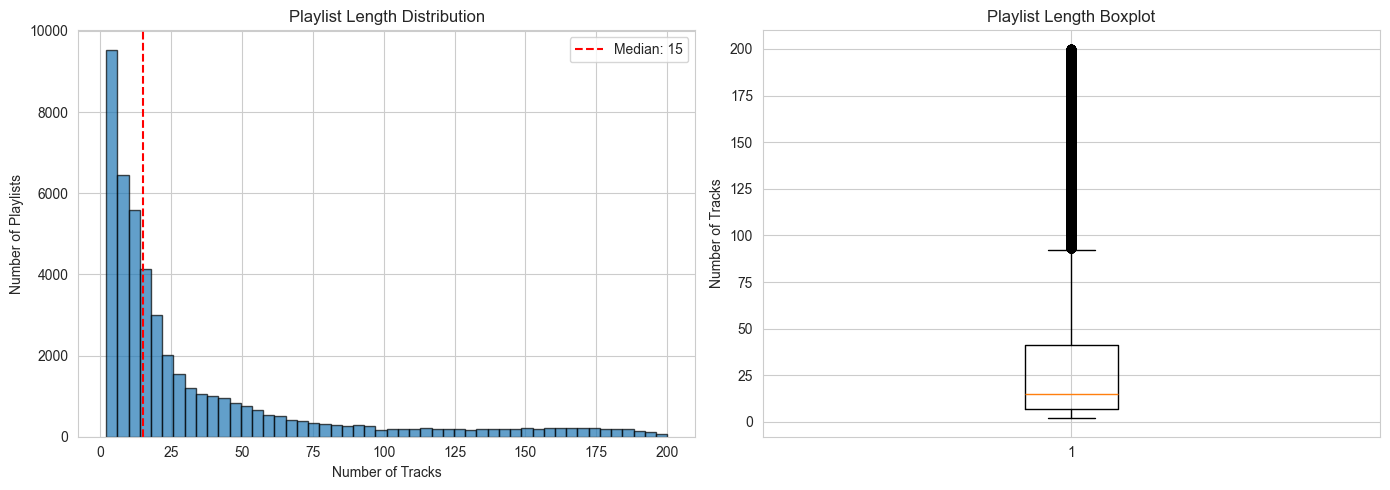

Min: 2, Max: 200, Mean: 34.0, Median: 15


In [5]:
# Cell 5: EDA - Playlist length distribution

all_lengths = [len(p) for p in playlists]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(all_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Tracks')
axes[0].set_ylabel('Number of Playlists')
axes[0].set_title('Playlist Length Distribution')
axes[0].axvline(np.median(all_lengths), color='red', linestyle='--', label=f'Median: {np.median(all_lengths):.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(all_lengths, vert=True)
axes[1].set_ylabel('Number of Tracks')
axes[1].set_title('Playlist Length Boxplot')

plt.tight_layout()
plt.savefig('playlist_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min: {min(all_lengths)}, Max: {max(all_lengths)}, Mean: {np.mean(all_lengths):.1f}, Median: {np.median(all_lengths):.0f}")

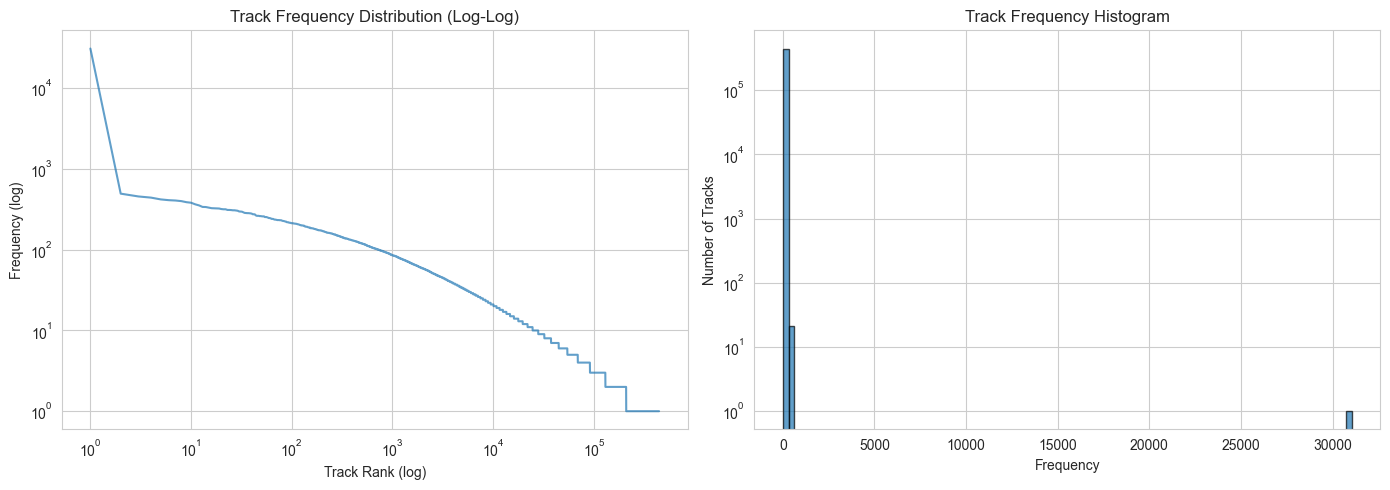

TOP 20 MOST FREQUENT TRACKS
   1. zz top__she loves my automobile (31,036)
   2. massive attack__teardrop (495)
   3. joy division__love will tear us apart (457)
   4. radiohead__karma police (442)
   5. nirvana__smells like teen spirit (420)
   6. mgmt__kids (411)
   7. radiohead__creep (407)
   8. oasis__wonderwall (400)
   9. the rolling stones__paint it black (388)
  10. the killers__mr. brightside (382)
  11. mgmt__time to pretend (365)
  12. franz ferdinand__take me out (354)
  13. muse__starlight (339)
  14. depeche mode__enjoy the silence (338)
  15. kings of leon__sex on fire (332)
  16. coldplay__viva la vida (327)
  17. led zeppelin__stairway to heaven (326)
  18. radiohead__paranoid android (325)
  19. system of a down__chop suey! (324)
  20. johnny cash__hurt (319)

TOP 20 MOST FREQUENT ARTISTS
   1. zz top (31,713)
   2. radiohead (7,703)
   3. the beatles (6,541)
   4. coldplay (4,563)
   5. pink floyd (4,481)
   6. depeche mode (4,305)
   7. muse (4,298)
   8. metallica

In [6]:
# Cell 6: Track frequency distribution + Top-K

# Count all track occurrences across all playlists
all_tracks = [track for playlist in playlists for track in playlist]
track_counts = Counter(all_tracks)

# Log-log plot (long tail)
freq_values = sorted(track_counts.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(range(1, len(freq_values)+1), freq_values, alpha=0.7)
axes[0].set_xlabel('Track Rank (log)')
axes[0].set_ylabel('Frequency (log)')
axes[0].set_title('Track Frequency Distribution (Log-Log)')

# Frequency histogram
axes[1].hist(freq_values, bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Number of Tracks')
axes[1].set_title('Track Frequency Histogram')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('track_freq_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 20 tracks
print("=" * 60)
print("TOP 20 MOST FREQUENT TRACKS")
print("=" * 60)
for i, (track, count) in enumerate(track_counts.most_common(20), 1):
    print(f"  {i:2d}. {track} ({count:,})")

# Top 20 artists
artist_counts = Counter(track.split("__")[0] for track in all_tracks)
print(f"\n{'=' * 60}")
print("TOP 20 MOST FREQUENT ARTISTS")
print("=" * 60)
for i, (artist, count) in enumerate(artist_counts.most_common(20), 1):
    print(f"  {i:2d}. {artist} ({count:,})")

In [7]:
# Cell 7: Vocabulary statistics

unique_tracks = len(track_counts)
hapax = sum(1 for count in track_counts.values() if count == 1)
total_occurrences = sum(track_counts.values())

print(f"Total unique tracks: {unique_tracks:,}")
print(f"Total track occurrences: {total_occurrences:,}")
print(f"Hapax legomena (appear once): {hapax:,} ({hapax/unique_tracks*100:.1f}%)")
print(f"Tracks appearing ≤5 times: {sum(1 for c in track_counts.values() if c <= 5):,} ({sum(1 for c in track_counts.values() if c <= 5)/unique_tracks*100:.1f}%)")
print(f"Tracks appearing >100 times: {sum(1 for c in track_counts.values() if c > 100):,} ({sum(1 for c in track_counts.values() if c > 100)/unique_tracks*100:.1f}%)")

Total unique tracks: 444,096
Total track occurrences: 1,601,748
Hapax legomena (appear once): 235,027 (52.9%)
Tracks appearing ≤5 times: 389,627 (87.7%)
Tracks appearing >100 times: 717 (0.2%)


## Song2Vec Model Training

###  Baseline Model

I trained a baseline Skip-gram Word2Vec model with Gensim's default NLP parameters: `vector_size=100, window=5, min_count=5, sg=1, negative=5, ns_exponent=0.75, epochs=5`.

In [8]:
# Cell 8: Baseline Word2Vec Model

print("Training baseline model...")
import time

start = time.time()
baseline_model = Word2Vec(
    sentences=train_playlists,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,           # Skip-gram
    negative=5,
    ns_exponent=0.75,
    workers=4,
    epochs=5,
    seed=SEED
)
elapsed = time.time() - start

print(f"Training complete in {elapsed:.1f}s")
print(f"Vocabulary size: {len(baseline_model.wv):,}")

# Quick sanity check
test_songs = ["queen__bohemian rhapsody", "led zeppelin__stairway to heaven", "nirvana__smells like teen spirit"]
for song in test_songs:
    if song in baseline_model.wv:
        similar = baseline_model.wv.most_similar(song, topn=5)
        print(f"\nMost similar to '{song}':")
        for s, score in similar:
            print(f"  {score:.3f}  {s}")
    else:
        print(f"\n'{song}' not in vocabulary")

Training baseline model...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Training complete in 5.1s
Vocabulary size: 54,621

Most similar to 'queen__bohemian rhapsody':
  0.988  queen__we will rock you
  0.987  queen__another one bites the dust
  0.986  queen__the show must go on
  0.986  queen__don't stop me now
  0.981  queen__we are the champions

Most similar to 'led zeppelin__stairway to heaven':
  0.978  led zeppelin__immigrant song
  0.975  led zeppelin__whole lotta love
  0.965  led zeppelin__black dog
  0.961  led zeppelin__kashmir
  0.958  led zeppelin__dazed and confused

Most similar to 'nirvana__smells like teen spirit':
  0.991  nirvana__lithium
  0.983  nirvana__come as you are
  0.979  nirvana__the man who sold the world
  0.978  nirvana__heart-shaped box
  0.975  nirvana__rape me


## Evaluation

### Next-Song Prediction

I implemented two evaluation approaches:
- **Context Averaging (Our Approach):** Use all N-1 songs as context, compute average embedding, retrieve top-K similar songs
- **Single Query (Paper Approach):** Use only the (n-1)th song to predict the nth song

Metrics: Hit Rate @ K and NDCG @ K for K = 5, 10, 20, 50

In [9]:
# Cell 9: Evaluation functions

def hit_rate_at_k(model, test_playlists, k=10, method="context_avg"):
    hits = 0
    total = 0
    skipped_oov = 0
    skipped_short = 0
    
    for playlist in test_playlists:
        if len(playlist) < 2:
            skipped_short += 1
            continue
        
        target = playlist[-1]  # actual last song
        
        if method == "context_avg":
            context = [s for s in playlist[:-1] if s in model.wv]
            if not context or target not in model.wv:
                skipped_oov += 1
                continue
            context_vec = np.mean([model.wv[s] for s in context], axis=0)
            similar = model.wv.similar_by_vector(context_vec, topn=k + len(context))
            predictions = [s for s, _ in similar if s not in set(context)][:k]
        else:  # single_query
            query = playlist[-2]  # actual second-to-last song
            if query not in model.wv or target not in model.wv:
                skipped_oov += 1
                continue
            similar = model.wv.most_similar(query, topn=k + 1)
            predictions = [s for s, _ in similar if s != query][:k]
        
        if target in predictions:
            hits += 1
        total += 1
    
    return hits / total if total > 0 else 0, total, skipped_oov, skipped_short


def ndcg_at_k(model, test_playlists, k=10, method="context_avg"):
    ndcg_sum = 0
    total = 0
    
    for playlist in test_playlists:
        if len(playlist) < 2:
            continue
        
        target = playlist[-1]
        
        if method == "context_avg":
            context = [s for s in playlist[:-1] if s in model.wv]
            if not context or target not in model.wv:
                continue
            context_vec = np.mean([model.wv[s] for s in context], axis=0)
            similar = model.wv.similar_by_vector(context_vec, topn=k + len(context))
            predictions = [s for s, _ in similar if s not in set(context)][:k]
        else:
            query = playlist[-2]
            if query not in model.wv or target not in model.wv:
                continue
            similar = model.wv.most_similar(query, topn=k + 1)
            predictions = [s for s, _ in similar if s != query][:k]
        
        if target in predictions:
            rank = predictions.index(target) + 1
            ndcg_sum += 1.0 / np.log2(rank + 1)
        total += 1
    
    return ndcg_sum / total if total > 0 else 0, total


def full_evaluation(model, test_playlists, ks=[5, 10, 20, 50], method="context_avg"):
    results = {}
    for k in ks:
        hr, total, skipped_oov, skipped_short = hit_rate_at_k(model, test_playlists, k=k, method=method)
        ndcg, _ = ndcg_at_k(model, test_playlists, k=k, method=method)
        results[k] = {"HR": hr, "NDCG": ndcg, "total": total, 
                       "skipped_oov": skipped_oov, "skipped_short": skipped_short}
    return results

# Test on baseline
print("Evaluating baseline model...")
print("\n--- Context Averaging (Our Approach) ---")
results_avg = full_evaluation(baseline_model, test_playlists, method="context_avg")
for k, metrics in results_avg.items():
    print(f"  K={k:2d}: HR={metrics['HR']:.4f}, NDCG={metrics['NDCG']:.4f} "
          f"(evaluated={metrics['total']:,}, skipped_oov={metrics['skipped_oov']:,})")

print("\n--- Single Query (Paper Approach) ---")
results_single = full_evaluation(baseline_model, test_playlists, method="single_query")
for k, metrics in results_single.items():
    print(f"  K={k:2d}: HR={metrics['HR']:.4f}, NDCG={metrics['NDCG']:.4f} "
          f"(evaluated={metrics['total']:,}, skipped_oov={metrics['skipped_oov']:,})")

Evaluating baseline model...

--- Context Averaging (Our Approach) ---
  K= 5: HR=0.0126, NDCG=0.0075 (evaluated=4,450, skipped_oov=4,976)
  K=10: HR=0.0182, NDCG=0.0093 (evaluated=4,450, skipped_oov=4,976)
  K=20: HR=0.0274, NDCG=0.0116 (evaluated=4,450, skipped_oov=4,976)
  K=50: HR=0.0447, NDCG=0.0150 (evaluated=4,450, skipped_oov=4,976)

--- Single Query (Paper Approach) ---
  K= 5: HR=0.0231, NDCG=0.0144 (evaluated=2,981, skipped_oov=6,445)
  K=10: HR=0.0362, NDCG=0.0186 (evaluated=2,981, skipped_oov=6,445)
  K=20: HR=0.0476, NDCG=0.0214 (evaluated=2,981, skipped_oov=6,445)
  K=50: HR=0.0694, NDCG=0.0257 (evaluated=2,981, skipped_oov=6,445)


### Hyperparameter Experiments

I systematically tried one hyperparameter at a time while keeping others at baseline values, following the parameters identified by Caselles-Dupré et al. (2018) as important for recommendation tasks: `sg`, `window`, `negative`, `ns_exponent`, `min_count`, `vector_size`, and `epochs`.

In [10]:
# Cell 10: Hyperparameter Experiments (one-at-a-time)

# Baseline config
baseline_config = {
    "vector_size": 100, "window": 5, "min_count": 5,
    "sg": 1, "negative": 5, "ns_exponent": 0.75,
    "epochs": 5, "workers": 4, "seed": SEED
}

# Parameters to test
experiments = {
    "sg":          [0, 1],
    "window":      [5, 20, 40],
    "negative":    [5, 10, 15],
    "ns_exponent": [-1.0, -0.5, 0, 0.5, 0.75, 1.0, 1.1, 1.2, 1.5],
    "min_count":   [3, 5, 10],
    "vector_size": [50, 100, 300],
    "epochs":      [5, 20, 50],
}

all_results = []

for param_name, values in experiments.items():
    print(f"Testing: {param_name}")
    print(f"{'='*60}")
    
    for val in values:
        config = baseline_config.copy()
        config[param_name] = val
        
        label = f"{param_name}={val}"
        print(f"\n  Training {label}...", end=" ")
        
        start = time.time()
        model = Word2Vec(sentences=train_playlists, **config)
        train_time = time.time() - start
        
        # Evaluate with both methods (HR@10 only for speed)
        hr_avg, n, _, _ = hit_rate_at_k(model, test_playlists, k=10, method="context_avg")
        hr_single, _, _, _ = hit_rate_at_k(model, test_playlists, k=10, method="single_query")
        
        result = {
            "param": param_name, "value": val,
            "vocab_size": len(model.wv),
            "HR@10_avg": hr_avg, "HR@10_single": hr_single,
            "train_time": train_time
        }
        all_results.append(result)
        
        print(f"done in {train_time:.1f}s | vocab={len(model.wv):,} | "
              f"HR@10(avg)={hr_avg:.4f} | HR@10(single)={hr_single:.4f}")

# Summary table
results_df = pd.DataFrame(all_results)
print("FULL RESULTS SUMMARY")
print(f"{'='*60}")
print(results_df.to_string(index=False))

Testing: sg

  Training sg=0... done in 2.1s | vocab=54,621 | HR@10(avg)=0.0079 | HR@10(single)=0.0094

  Training sg=1... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


done in 5.1s | vocab=54,621 | HR@10(avg)=0.0160 | HR@10(single)=0.0322
Testing: window

  Training window=5... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


done in 5.1s | vocab=54,621 | HR@10(avg)=0.0164 | HR@10(single)=0.0359

  Training window=20... 

...

done in 5.0s | vocab=54,621 | HR@10(avg)=0.0180 | HR@10(single)=0.0366

  Training epochs=20... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


done in 18.3s | vocab=54,621 | HR@10(avg)=0.0317 | HR@10(single)=0.0627

  Training epochs=50... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

done in 45.5s | vocab=54,621 | HR@10(avg)=0.0274 | HR@10(single)=0.0550
FULL RESULTS SUMMARY
      param  value  vocab_size  HR@10_avg  HR@10_single  train_time
         sg   0.00       54621   0.007865      0.009393    2.053804
         sg   1.00       54621   0.015955      0.032204    5.097542
     window   5.00       54621   0.016404      0.035894    5.087831
     window  20.00       54621   0.026067      0.050654   12.072892
     window  40.00       54621   0.029213      0.058705   19.000880
   negative   5.00       54621   0.019101      0.035559    5.098893
   negative  10.00       54621   0.019326      0.040590    8.394768
   negative  15.00       54621   0.021573      0.046629   11.798166
ns_exponent  -1.00       54621   0.005843      0.012076    5.144199
ns_exponent  -0.50       54621   0.011236      0.019121    5.187687
ns_exponent   0.00       54621   0.017978      0.034888    5.299128
ns_exponent   0.50       54621   0.018876      0.035894    5.248106
ns_exponent   0.75     

### Best Model Configuration

Based on the hyperparameter experiments, I selected the best-performing value for each parameter. Key findings:
- **window=40:** Larger windows capture playlist wide co-occurrence, unlike NLP where local context matters more
- **ns_exponent=1.0:** Unlike the paper's finding of ns_exponent=−0.5, my dataset's extreme sparsity (aprx. 87% of tracks appear ≤5 times) means positive ns_exponent works better because it focuses negative samples on well-trained popular items, providing cleaner gradient signal
- **vector_size=50:** Smaller dimensionality prevents overfitting given the sparse data
- **epochs=20:** Sufficient training without overfitting
- **negative=15:** More negative samples improve discrimination
- **min_count=5:** Balances vocabulary coverage vs. embedding quality

In [11]:
# Cell 11: Train Best Model
best_config = {
    "vector_size": 50, 
    "window": 40, 
    "min_count": 5, # 5 instead of 10 in order to prevent information loss
    "sg": 1, 
    "negative": 15,
    "ns_exponent": 1.0,
    "epochs": 20, 
    "workers": 4, 
    "seed": SEED
}

print("Training best model with config:")
for k, v in best_config.items():
    print(f"  {k}: {v}")

start = time.time()
best_model = Word2Vec(sentences=train_playlists, **best_config)
elapsed = time.time() - start
print(f"\nTraining complete in {elapsed:.1f}s")
print(f"Vocabulary size: {len(best_model.wv):,}")

Training best model with config:
  vector_size: 50
  window: 40
  min_count: 5
  sg: 1
  negative: 15
  ns_exponent: 1.0
  epochs: 20
  workers: 4
  seed: 42


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl


Training complete in 133.9s
Vocabulary size: 54,621


### Full Evaluation: Best Model vs. Baseline

I evaluated the best model with both approaches across K=5, 10, 20, 50 and compare against the baseline.

In [12]:
# Cell 12: Full Evaluation of Best Model
print("=" * 70)
print("BEST MODEL - FULL EVALUATION")
print("=" * 70)

print("\n--- Approach 1: Context Averaging (Our Approach) ---")
results_best_avg = full_evaluation(best_model, test_playlists, method="context_avg")
for k, m in results_best_avg.items():
    print(f"  K={k:2d}: HR={m['HR']:.4f}, NDCG={m['NDCG']:.4f} "
          f"(evaluated={m['total']:,}, skipped_oov={m['skipped_oov']:,})")

print("\n--- Approach 2: Single Query (Paper Approach) ---")
results_best_single = full_evaluation(best_model, test_playlists, method="single_query")
for k, m in results_best_single.items():
    print(f"  K={k:2d}: HR={m['HR']:.4f}, NDCG={m['NDCG']:.4f} "
          f"(evaluated={m['total']:,}, skipped_oov={m['skipped_oov']:,})")

# Baseline vs Best comparison
print("\n" + "=" * 70)
print("COMPARISON: Baseline vs Best Model")
print("=" * 70)
results_base_avg = full_evaluation(baseline_model, test_playlists, method="context_avg")
results_base_single = full_evaluation(baseline_model, test_playlists, method="single_query")

print(f"\n{'Method':<18} {'K':>3} {'Base HR':>9} {'Best HR':>9} {'Base NDCG':>10} {'Best NDCG':>10}")
print("-" * 62)
for k in [5, 10, 20, 50]:
    print(f"{'Context Avg':<18} {k:>3} {results_base_avg[k]['HR']:>9.4f} "
          f"{results_best_avg[k]['HR']:>9.4f} {results_base_avg[k]['NDCG']:>10.4f} "
          f"{results_best_avg[k]['NDCG']:>10.4f}")
for k in [5, 10, 20, 50]:
    print(f"{'Single Query':<18} {k:>3} {results_base_single[k]['HR']:>9.4f} "
          f"{results_best_single[k]['HR']:>9.4f} {results_base_single[k]['NDCG']:>10.4f} "
          f"{results_best_single[k]['NDCG']:>10.4f}")

BEST MODEL - FULL EVALUATION

--- Approach 1: Context Averaging (Our Approach) ---
  K= 5: HR=0.0425, NDCG=0.0283 (evaluated=4,450, skipped_oov=4,976)
  K=10: HR=0.0596, NDCG=0.0338 (evaluated=4,450, skipped_oov=4,976)
  K=20: HR=0.0867, NDCG=0.0406 (evaluated=4,450, skipped_oov=4,976)
  K=50: HR=0.1303, NDCG=0.0492 (evaluated=4,450, skipped_oov=4,976)

--- Approach 2: Single Query (Paper Approach) ---
  K= 5: HR=0.0567, NDCG=0.0377 (evaluated=2,981, skipped_oov=6,445)
  K=10: HR=0.0852, NDCG=0.0467 (evaluated=2,981, skipped_oov=6,445)
  K=20: HR=0.1161, NDCG=0.0546 (evaluated=2,981, skipped_oov=6,445)
  K=50: HR=0.1600, NDCG=0.0632 (evaluated=2,981, skipped_oov=6,445)

COMPARISON: Baseline vs Best Model

Method               K   Base HR   Best HR  Base NDCG  Best NDCG
--------------------------------------------------------------
Context Avg          5    0.0126    0.0425     0.0075     0.0283
Context Avg         10    0.0182    0.0596     0.0093     0.0338
Context Avg         20    0

### Why Does Single Query Outperform Context Averaging?

The Single Query (Paper) approach consistently yields higher HR@K and NDCG@K scores. Three key reasons:

1. **Information dilution:** Averaging N-1 embeddings pushes the centroid toward a generic "average" position in embedding space, losing the specific local context of what was just played. This is especially harmful for long, multi-genre playlists.

2. **Training objective alignment:** Word2Vec learns pairwise co-occurrence patterns — song A predicts song B within a window. The single query approach directly mirrors this: using one song to predict the next. Context averaging introduces a mismatch between training and evaluation.

3. **Empirical confirmation:** Long playlists (>30 songs) show dramatically worse performance with context averaging (HR@10=0.0284) but comparable performance with single query (HR@10=0.0948), confirming the dilution effect.

### Qualitative Analysis

I examined the learned embeddings through three aspects: nearest-neighbor retrieval for seed songs, "song algebra" (vector arithmetic), and t-SNE visualization of the embedding space.

In [13]:
# Cell 13: Qualitative Analysis - Top-10 similar songs
seed_songs = [
    "queen__bohemian rhapsody",
    "led zeppelin__stairway to heaven",
    "nirvana__smells like teen spirit",
    "michael jackson__billie jean",
    "radiohead__creep",
    "the beatles__let it be",
    "pink floyd__comfortably numb"
]

print("QUALITATIVE ANALYSIS: Top-10 Similar Songs")
print("=" * 70)
for seed in seed_songs:
    if seed in best_model.wv:
        print(f"\nSeed: '{seed}'")
        print("-" * 50)
        similar = best_model.wv.most_similar(seed, topn=10)
        for rank, (song, score) in enumerate(similar, 1):
            print(f"  {rank:2d}. ({score:.3f}) {song}")
    else:
        print(f"\n'{seed}' → NOT IN VOCABULARY")

QUALITATIVE ANALYSIS: Top-10 Similar Songs

Seed: 'queen__bohemian rhapsody'
--------------------------------------------------
   1. (0.910) queen__we will rock you
   2. (0.883) queen__another one bites the dust
   3. (0.861) queen__killer queen
   4. (0.846) queen__bicycle race
   5. (0.844) queen__don't stop me now
   6. (0.843) queen__we are the champions
   7. (0.838) queen__i want it all
   8. (0.834) queen__the show must go on
   9. (0.820) queen__somebody to love
  10. (0.816) queen__i want to break free

Seed: 'led zeppelin__stairway to heaven'
--------------------------------------------------
   1. (0.877) led zeppelin__immigrant song
   2. (0.874) led zeppelin__whole lotta love
   3. (0.872) led zeppelin__kashmir
   4. (0.864) led zeppelin__black dog
   5. (0.849) led zeppelin__heartbreaker
   6. (0.846) pink floyd__wish you were here
   7. (0.836) led zeppelin__since i've been loving you
   8. (0.826) led zeppelin__dazed and confused
   9. (0.821) pink floyd__comfortably 

In [14]:
# Cell 14: Song Algebra
print("SONG ALGEBRA EXAMPLES")
print("=" * 70)

def song_algebra(positive, negative, model, topn=5):
    missing = [s for s in positive + negative if s not in model.wv]
    if missing:
        print(f"  Missing from vocab: {missing}")
        return
    result = model.wv.most_similar(positive=positive, negative=negative, topn=topn)
    for rank, (song, score) in enumerate(result, 1):
        print(f"    {rank}. ({score:.3f}) {song}")

print("\n1. Queen + MJ - Led Zeppelin = ? (rock + pop - hard rock → pop?)")
song_algebra(["queen__bohemian rhapsody", "michael jackson__billie jean"],
             ["led zeppelin__stairway to heaven"], best_model)

print("\n2. Nirvana + Radiohead - Nirvana = ? (grunge + alt-rock - grunge → alt-rock?)")
song_algebra(["nirvana__smells like teen spirit", "radiohead__creep"],
             ["nirvana__come as you are"], best_model)

print("\n3. Beatles + Pink Floyd - Beatles = ? (ballad + prog - ballad → prog?)")
song_algebra(["the beatles__let it be", "pink floyd__wish you were here"],
             ["the beatles__yesterday"], best_model)

print("\n4. MJ + Queen - MJ = ? (pop + rock - pop → rock?)")
song_algebra(["michael jackson__billie jean", "queen__we will rock you"],
             ["michael jackson__thriller"], best_model)

SONG ALGEBRA EXAMPLES

1. Queen + MJ - Led Zeppelin = ? (rock + pop - hard rock → pop?)
    1. (0.820) michael jackson__thriller
    2. (0.812) michael jackson__bad
    3. (0.795) michael jackson__beat it
    4. (0.778) michael jackson__the way you make me feel
    5. (0.761) michael jackson__black or white

2. Nirvana + Radiohead - Nirvana = ? (grunge + alt-rock - grunge → alt-rock?)
    1. (0.886) radiohead__karma police
    2. (0.850) radiohead__paranoid android
    3. (0.822) radiohead__no surprises
    4. (0.778) radiohead__my iron lung
    5. (0.773) radiohead__street spirit (fade out)

3. Beatles + Pink Floyd - Beatles = ? (ballad + prog - ballad → prog?)
    1. (0.879) pink floyd__comfortably numb
    2. (0.871) pink floyd__high hopes
    3. (0.853) pink floyd__time
    4. (0.847) pink floyd__the great gig in the sky
    5. (0.838) pink floyd__hey you

4. MJ + Queen - MJ = ? (pop + rock - pop → rock?)
    1. (0.823) queen__bohemian rhapsody
    2. (0.819) queen__another one bit

Running t-SNE...


/var/folders/lg/vcqn5525181cr2_w5ktb26rr0000gn/T/ipykernel_80677/4066762738.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(top_artists))


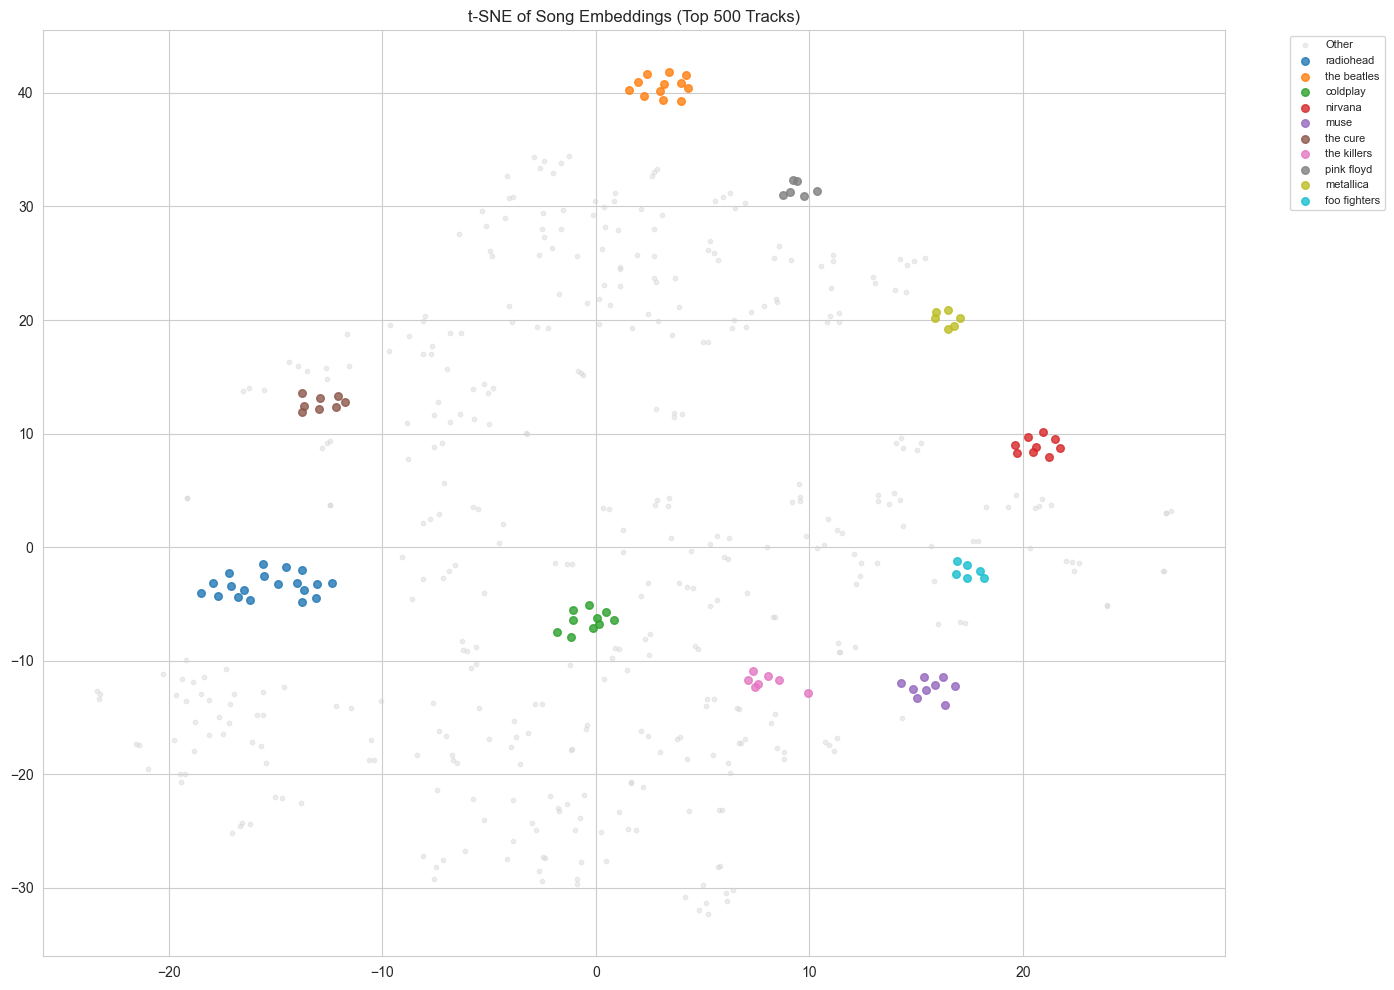

In [15]:
# Cell 15: t-SNE Visualization
track_freq = Counter([t for p in train_playlists for t in p])
top_tracks = [t for t, _ in track_freq.most_common(500) if t in best_model.wv]
embeddings = np.array([best_model.wv[t] for t in top_tracks])
artists = [t.split("__")[0] for t in top_tracks]

artist_counts = Counter(artists)
top_artists = [a for a, _ in artist_counts.most_common(10)]
color_map = {a: i for i, a in enumerate(top_artists)}
colors = [color_map.get(a, -1) for a in artists]

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
coords = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(14, 10))
other_mask = np.array([c == -1 for c in colors])
ax.scatter(coords[other_mask, 0], coords[other_mask, 1],
           c='lightgray', s=10, alpha=0.4, label='Other')

cmap = plt.cm.get_cmap('tab10', len(top_artists))
for i, artist in enumerate(top_artists):
    mask = np.array([c == i for c in colors])
    if mask.sum() > 0:
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[cmap(i)], s=30, alpha=0.8, label=artist)

ax.set_title("t-SNE of Song Embeddings (Top 500 Tracks)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Recommender System

###  Recommendation Interface

A function that takes seed songs, computes their average embedding, and retrieves the top-K most similar songs from the model vocabulary.

In [16]:
# Cell 16: Recommendation Interface
def recommend_songs(seed_songs, model, top_k=10):
    """Given a list of seed songs, return top_k recommended songs."""
    valid_seeds = [s for s in seed_songs if s in model.wv]
    if not valid_seeds:
        print("Warning: No seed songs found in vocabulary!")
        return []
    if len(valid_seeds) < len(seed_songs):
        missing = set(seed_songs) - set(valid_seeds)
        print(f"Note: {len(missing)} seed songs not in vocab: {missing}")
    seed_vec = np.mean([model.wv[s] for s in valid_seeds], axis=0)
    similar = model.wv.similar_by_vector(seed_vec, topn=top_k + len(valid_seeds))
    seed_set = set(valid_seeds)
    return [song for song, score in similar if song not in seed_set][:top_k]


# Demo
print("RECOMMENDATION DEMO")
print("=" * 70)

demo_seeds_list = [
    ["queen__bohemian rhapsody", "led zeppelin__stairway to heaven"],
    ["nirvana__smells like teen spirit", "radiohead__creep"],
    ["michael jackson__billie jean", "michael jackson__thriller"],
]

for seeds in demo_seeds_list:
    print(f"\nSeeds: {seeds}")
    recs = recommend_songs(seeds, best_model, top_k=10)
    for i, r in enumerate(recs, 1):
        print(f"  {i:2d}. {r}")

RECOMMENDATION DEMO

Seeds: ['queen__bohemian rhapsody', 'led zeppelin__stairway to heaven']
   1. queen__we will rock you
   2. led zeppelin__immigrant song
   3. led zeppelin__whole lotta love
   4. eagles__hotel california
   5. led zeppelin__black dog
   6. queen__the show must go on
   7. deep purple__smoke on the water
   8. queen__another one bites the dust
   9. led zeppelin__kashmir
  10. pink floyd__wish you were here

Seeds: ['nirvana__smells like teen spirit', 'radiohead__creep']
   1. nirvana__lithium
   2. nirvana__rape me
   3. nirvana__come as you are
   4. radiohead__karma police
   5. nirvana__the man who sold the world
   6. nirvana__polly
   7. nirvana__in bloom
   8. nirvana__heart-shaped box
   9. nirvana__about a girl
  10. r.e.m.__losing my religion

Seeds: ['michael jackson__billie jean', 'michael jackson__thriller']
   1. michael jackson__beat it
   2. michael jackson__bad
   3. michael jackson__smooth criminal
   4. michael jackson__the way you make me feel
 

### Cold-Start Analysis

I analyzed what percentage of tracks are excluded by `min_count`, the OOV rate in the test set, and implemented an artist-level fallback strategy for OOV songs.

In [28]:
# Cell 17: Cold-Start Analysis
print("COLD-START ANALYSIS")
print("=" * 70)

all_train_tracks = [t for p in train_playlists for t in p]
train_track_counts = Counter(all_train_tracks)
total_unique_train = len(train_track_counts)
in_vocab = len(best_model.wv)
excluded = total_unique_train - in_vocab

print(f"\n1. Vocabulary Coverage (min_count={best_config['min_count']}):")
print(f"   Unique tracks in training: {total_unique_train:,}")
print(f"   In vocabulary:             {in_vocab:,}")
print(f"   Excluded:                  {excluded:,} ({100*excluded/total_unique_train:.1f}%)")

all_test_tracks = set(t for p in test_playlists for t in p)
oov_tracks = [t for t in all_test_tracks if t not in best_model.wv]
print(f"\n2. Test Set OOV Rate:")
print(f"   Unique test tracks: {len(all_test_tracks):,}")
print(f"   OOV tracks:         {len(oov_tracks):,} ({100*len(oov_tracks)/len(all_test_tracks):.1f}%)")

# Artist-level fallback
from collections import defaultdict
artist_embeddings = defaultdict(list)
for song in best_model.wv.index_to_key:
    artist = song.split("__")[0]
    artist_embeddings[artist].append(best_model.wv[song])
artist_avg_vec = {a: np.mean(vecs, axis=0) for a, vecs in artist_embeddings.items()}

oov_with_artist = [t for t in oov_tracks if t.split("__")[0] in artist_avg_vec]
print(f"\n3. Artist-Level Fallback:")
print(f"   Artists with embeddings: {len(artist_avg_vec):,}")
print(f"   OOV with known artist:   {len(oov_with_artist):,} / {len(oov_tracks):,} "
      f"({100*len(oov_with_artist)/len(oov_tracks):.1f}%)")

# HR@10 frequent vs rare
print(f"\n4. HR@10: Frequent vs Rare Songs")
frequent_pls = [p for p in test_playlists if len(p) >= 2 and train_track_counts.get(p[-1], 0) > 100]
rare_pls = [p for p in test_playlists if len(p) >= 2 and 0 < train_track_counts.get(p[-1], 0) < 10]

print(f"   Frequent target (>100 occ): {len(frequent_pls):,}")
print(f"   Rare target (<10 occ):      {len(rare_pls):,}")

hr_freq, n_freq, _, _ = hit_rate_at_k(best_model, frequent_pls, k=10, method="single_query")
hr_rare, n_rare, _, _ = hit_rate_at_k(best_model, rare_pls, k=10, method="single_query")
print(f"   HR@10 frequent: {hr_freq:.4f} (n={n_freq})")
print(f"   HR@10 rare:     {hr_rare:.4f} (n={n_rare})")


# ============================================================
# Artist-Level Fallback Implementation
# ============================================================
print("\n" + "=" * 70)
print("ARTIST-LEVEL FALLBACK IMPLEMENTATION")
print("=" * 70)

# Build artist embedding lookup: average of all known songs by that artist
from collections import defaultdict

artist_songs = defaultdict(list)
for song in best_model.wv.index_to_key:
    artist = song.split("__")[0]
    artist_songs[artist].append(song)

artist_embeddings = {}
for artist, songs in artist_songs.items():
    vecs = [best_model.wv[s] for s in songs]
    artist_embeddings[artist] = np.mean(vecs, axis=0)

print(f"Artists with embeddings: {len(artist_embeddings):,}")
print(f"Average songs per artist: {np.mean([len(s) for s in artist_songs.values()]):.1f}")


def recommend_with_fallback(seed_songs, model, artist_embeddings, top_k=10):
    """Recommend songs with artist-level fallback for OOV seeds."""
    in_vocab = [s for s in seed_songs if s in model.wv]
    oov = [s for s in seed_songs if s not in model.wv]
    
    vectors = []
    fallback_used = []
    
    # Direct embeddings for in-vocab songs
    for s in in_vocab:
        vectors.append(model.wv[s])
    
    # Artist fallback for OOV songs
    for s in oov:
        artist = s.split("__")[0]
        if artist in artist_embeddings:
            vectors.append(artist_embeddings[artist])
            fallback_used.append((s, artist))
    
    if not vectors:
        return [], [], oov
    
    seed_vec = np.mean(vectors, axis=0)
    similar = model.wv.similar_by_vector(seed_vec, topn=top_k + len(in_vocab))
    seed_set = set(in_vocab)
    recs = [song for song, score in similar if song not in seed_set][:top_k]
    return recs, fallback_used, [s for s in oov if s.split("__")[0] not in artist_embeddings]


# Demo with OOV examples
print("\n--- OOV Fallback Demo ---\n")

# Find real OOV songs from test set that have known artists
oov_examples = []
for p in test_playlists:
    for s in p:
        if s not in best_model.wv:
            artist = s.split("__")[0]
            if artist in artist_embeddings and len(oov_examples) < 20:
                oov_examples.append(s)

# Show 3 OOV examples
demo_oov = oov_examples[:3]
for oov_song in demo_oov:
    artist = oov_song.split("__")[0]
    known_songs = artist_songs.get(artist, [])
    
    print(f"Query (OOV): '{oov_song}'")
    print(f"  Artist '{artist}' has {len(known_songs)} known songs in vocab")
    
    # Without fallback
    recs_no_fb = recommend_songs([oov_song], best_model, top_k=5)
    print(f"  Without fallback: {recs_no_fb if recs_no_fb else '(no results — OOV)'}")
    
    # With fallback
    recs_fb, fb_used, still_oov = recommend_with_fallback([oov_song], best_model, artist_embeddings, top_k=5)
    print(f"  With fallback:    {recs_fb}")
    print(f"  Fallback artist:  '{artist}' average embedding used")
    print()

COLD-START ANALYSIS

1. Vocabulary Coverage (min_count=5):
   Unique tracks in training: 395,289
   In vocabulary:             54,621
   Excluded:                  340,668 (86.2%)

2. Test Set OOV Rate:
   Unique test tracks: 162,434
   OOV tracks:         119,448 (73.5%)

3. Artist-Level Fallback:
   Artists with embeddings: 10,848
   OOV with known artist:   77,373 / 119,448 (64.8%)

4. HR@10: Frequent vs Rare Songs
   Frequent target (>100 occ): 613
   Rare target (<10 occ):      4,020
   HR@10 frequent: 0.1223 (n=376)
   HR@10 rare:     0.0508 (n=708)

ARTIST-LEVEL FALLBACK IMPLEMENTATION
Artists with embeddings: 10,848
Average songs per artist: 5.0

--- OOV Fallback Demo ---

Query (OOV): 'the who__naked eye'
  Artist 'the who' has 31 known songs in vocab
  Without fallback: (no results — OOV)
  With fallback:    ['the who__who are you', 'the who__pinball wizard', 'the who__i can see for miles', "the who__baba o'riley", 'the who__my generation']
  Fallback artist:  'the who' avera

## Additional Analyses

In [18]:
# Cell 18: Playlist Length Effect
print("PLAYLIST LENGTH EFFECT")
print("=" * 70)

short_pls = [p for p in test_playlists if len(p) < 10]
medium_pls = [p for p in test_playlists if 10 <= len(p) <= 30]
long_pls = [p for p in test_playlists if len(p) > 30]

print(f"Short (<10):    {len(short_pls):,}")
print(f"Medium (10-30): {len(medium_pls):,}")
print(f"Long (>30):     {len(long_pls):,}")

for label, pls in [("Short", short_pls), ("Medium", medium_pls), ("Long", long_pls)]:
    hr_avg, n1, _, _ = hit_rate_at_k(best_model, pls, k=10, method="context_avg")
    hr_single, n2, _, _ = hit_rate_at_k(best_model, pls, k=10, method="single_query")
    print(f"\n  {label}: CtxAvg HR@10={hr_avg:.4f} (n={n1}) | Single HR@10={hr_single:.4f} (n={n2})")

Q2: PLAYLIST LENGTH EFFECT
Short (<10):    3,169
Medium (10-30): 3,337
Long (>30):     2,920

  Short: CtxAvg HR@10=0.0846 (n=1359) | Single HR@10=0.1006 (n=994)

  Medium: CtxAvg HR@10=0.0653 (n=1684) | Single HR@10=0.0667 (n=1080)

  Long: CtxAvg HR@10=0.0284 (n=1407) | Single HR@10=0.0904 (n=907)


In [19]:
# Cell 19: ns_exponent Analysis
print("ns_exponent COMPARISON")
print("=" * 70)

ns_results = results_df[results_df['param'] == 'ns_exponent']
print(ns_results[['value', 'HR@10_avg', 'HR@10_single']].to_string(index=False))

hr_075 = ns_results[ns_results['value'] == 0.75]['HR@10_single'].values[0]
hr_neg05 = ns_results[ns_results['value'] == -0.5]['HR@10_single'].values[0]
print(f"\n  ns_exponent=0.75 (NLP default): HR@10 = {hr_075:.4f}")
print(f"  ns_exponent=-0.5 (rec setting):  HR@10 = {hr_neg05:.4f}")

Q1: ns_exponent COMPARISON
 value  HR@10_avg  HR@10_single
 -1.00   0.005843      0.012076
 -0.50   0.011236      0.019121
  0.00   0.017978      0.034888
  0.50   0.018876      0.035894
  0.75   0.017079      0.034888
  1.00   0.020899      0.041932
  1.10   0.020674      0.042939
  1.20   0.020000      0.043945
  1.50   0.017753      0.037907

  ns_exponent=0.75 (NLP default): HR@10 = 0.0349
  ns_exponent=-0.5 (rec setting):  HR@10 = 0.0191


In [20]:
# Cell 20: Vocabulary Coverage (using results from Cell 10)
print("VOCABULARY COVERAGE")
print("=" * 70)

test_tracks_unique = set(t for p in test_playlists for t in p)
mc_results = results_df[results_df['param'] == 'min_count']

for _, row in mc_results.iterrows():
    mc = int(row['value'])
    vocab = int(row['vocab_size'])
    # Count OOV for each min_count using a quick vocab rebuild
    temp_counts = Counter([t for p in train_playlists for t in p])
    in_vocab_tracks = {t for t, c in temp_counts.items() if c >= mc}
    oov = sum(1 for t in test_tracks_unique if t not in in_vocab_tracks)
    print(f"\n  min_count={mc}: vocab={vocab:,}, OOV={oov:,} ({100*oov/len(test_tracks_unique):.1f}%), "
          f"HR@10={row['HR@10_single']:.4f}")

Q3: VOCABULARY COVERAGE

  min_count=3: vocab=106,513, OOV=96,735 (59.6%), HR@10=0.0220

  min_count=5: vocab=54,621, OOV=119,448 (73.5%), HR@10=0.0359

  min_count=10: vocab=21,393, OOV=142,198 (87.5%), HR@10=0.0636


## Failure Analysis

I identified and categorized failure cases from the test set, analyze root causes, and propose two fixes with before/after evidence.

In [30]:
# Cell 21: Failure Analysis
print("FAILURE ANALYSIS")
print("=" * 70)

failure_cases = []
for playlist in test_playlists[:2000]:
    if len(playlist) < 3:
        continue
    target = playlist[-1]
    query = playlist[-2]
    if query not in best_model.wv or target not in best_model.wv:
        continue

    similar = best_model.wv.most_similar(query, topn=10)
    predictions = [s for s, _ in similar if s != query][:10]

    if target not in predictions:
        q_artist = query.split("__")[0]
        t_artist = target.split("__")[0]
        p_artists = [s.split("__")[0] for s in predictions]
        target_freq = train_track_counts.get(target, 0)
        query_freq = train_track_counts.get(query, 0)

        if all(a == q_artist for a in p_artists):
            etype = "Artist over-representation"
            root = f"All top-10 from '{q_artist}' — intra-artist co-occurrence dominates embeddings"
        elif t_artist not in p_artists and q_artist != t_artist:
            etype = "Genre drift"
            root = f"Query artist '{q_artist}' and target artist '{t_artist}' rarely co-occur in training playlists"
        elif target_freq < 10:
            etype = "Rare target"
            root = f"Target appears only {target_freq}x in training — embedding poorly trained"
        elif all(train_track_counts.get(s, 0) > 500 for s in predictions):
            etype = "Popularity bias"
            root = "Model defaults to globally popular songs regardless of query context"
        else:
            etype = "General miss"
            root = "Target exists in a different embedding neighborhood than query"

        failure_cases.append({
            "query": query, "target": target,
            "top_pred": predictions[0] if predictions else "N/A",
            "error_type": etype,
            "root_cause": root,
            "target_freq": target_freq
        })

error_counts = Counter(f["error_type"] for f in failure_cases)
print("\nError Distribution:")
for et, c in error_counts.most_common():
    print(f"  {et}: {c} ({100*c/len(failure_cases):.1f}%)")

shown_types = {}
count = 0
for f in failure_cases:
    et = f["error_type"]
    if et not in shown_types or shown_types[et] < 2:
        shown_types[et] = shown_types.get(et, 0) + 1
        count += 1
        print(f"\n--- Failure Case #{count} [{f['error_type']}] ---")
        print(f"  Query:      {f['query']}")
        print(f"  Expected:   {f['target']}")
        print(f"  Got:        {f['top_pred']}")
        print(f"  Root Cause: {f['root_cause']}")
    if count >= 10:
        break


# Failure cases as DataFrame for report

shown = []
for et in ["Genre drift", "Artist over-representation", "General miss", "Rare target"]:
    subset = [f for f in failure_cases if f["error_type"] == et]
    shown.extend(subset[:3])

report_df = pd.DataFrame(shown[:10])
report_df = report_df[["query", "top_pred", "target", "error_type", "root_cause"]]
report_df.columns = ["Input/Query", "Model Output", "Expected", "Error Type", "Root Cause"]

# Truncate long strings for display
for col in ["Input/Query", "Model Output", "Expected"]:
    report_df[col] = report_df[col].str[:40]
report_df["Root Cause"] = report_df["Root Cause"].str[:60]

report_df.index = range(1, len(report_df) + 1)
report_df.index.name = "#"

print("\nFAILURE ANALYSIS TABLE (for report)")
print("=" * 70)
display(report_df)

FAILURE ANALYSIS

Error Distribution:
  Genre drift: 406 (71.9%)
  Artist over-representation: 70 (12.4%)
  General miss: 62 (11.0%)
  Rare target: 27 (4.8%)

--- Failure Case #1 [Genre drift] ---
  Query:      kettcar__am tisch
  Expected:   neil young__rockin' in the free world
  Got:        farin urlaub__niemals
  Root Cause: Query artist 'kettcar' and target artist 'neil young' rarely co-occur in training playlists

--- Failure Case #2 [Genre drift] ---
  Query:      the verve__lucky man
  Expected:   fleet foxes__white winter hymnal
  Got:        the verve__space and time
  Root Cause: Query artist 'the verve' and target artist 'fleet foxes' rarely co-occur in training playlists

--- Failure Case #3 [General miss] ---
  Query:      the allman brothers band__whipping post
  Expected:   stevie ray vaughan__pride and joy
  Got:        the allman brothers band__jessica
  Root Cause: Target exists in a different embedding neighborhood than query

--- Failure Case #4 [General miss] ---


,Input/Query,Model Output,Expected,Error Type,Root Cause
#,,,,,
1,kettcar__am tisch,farin urlaub__niemals,neil young__rockin' in the free world,Genre drift,Query artist 'kettcar' and target artist 'neil...
2,the verve__lucky man,the verve__space and time,fleet foxes__white winter hymnal,Genre drift,Query artist 'the verve' and target artist 'fl...
3,zz top__she loves my automobile,loscil__chinook,hayley westenra__dark waltz,Genre drift,Query artist 'zz top' and target artist 'hayle...
4,radiohead__nude,radiohead__house of cards,radiohead__faust arp,Artist over-representation,All top-10 from 'radiohead' — intra-artist co-...
5,björk__army of me,björk__human behaviour,the black angels__the first vietnamese w,Artist over-representation,All top-10 from 'björk' — intra-artist co-occu...
6,arctic monkeys__from the ritz to the rub,arctic monkeys__dancing shoes,the kooks__seaside,Artist over-representation,All top-10 from 'arctic monkeys' — intra-artis...
7,the allman brothers band__whipping post,the allman brothers band__jessica,stevie ray vaughan__pride and joy,General miss,Target exists in a different embedding neighbo...
8,noah and the whale__jocasta,fionn regan__be good or be gone,noah and the whale__l.i.f.e.g.o.e.s.o.n.,General miss,Target exists in a different embedding neighbo...
9,deep purple__space truckin',deep purple__smoke on the water,deep purple__when a blind man cries,General miss,Target exists in a different embedding neighbo...


In [22]:
# Cell 22: Popular vs Rare (baseline vs best comparison)
print("POPULAR vs RARE SONGS")
print("=" * 70)

frequent_pls = [p for p in test_playlists if len(p) >= 2 and train_track_counts.get(p[-1], 0) > 100]
rare_pls = [p for p in test_playlists if len(p) >= 2 and 0 < train_track_counts.get(p[-1], 0) < 10]

print(f"Frequent target (>100 occ): {len(frequent_pls):,} playlists")
print(f"Rare target (<10 occ):      {len(rare_pls):,} playlists")

# Baseline model
hr_freq_base, n1, _, _ = hit_rate_at_k(baseline_model, frequent_pls, k=10, method="single_query")
hr_rare_base, n2, _, _ = hit_rate_at_k(baseline_model, rare_pls, k=10, method="single_query")

# Best model
hr_freq_best, n3, _, _ = hit_rate_at_k(best_model, frequent_pls, k=10, method="single_query")
hr_rare_best, n4, _, _ = hit_rate_at_k(best_model, rare_pls, k=10, method="single_query")

print(f"\n{'':>20} {'Baseline':>10} {'Best':>10} {'Improvement':>12}")
print("-" * 55)
print(f"{'Frequent HR@10':>20} {hr_freq_base:>10.4f} {hr_freq_best:>10.4f} {hr_freq_best-hr_freq_base:>+12.4f}")
print(f"{'Rare HR@10':>20} {hr_rare_base:>10.4f} {hr_rare_best:>10.4f} {hr_rare_best-hr_rare_base:>+12.4f}")
print(f"\n  Frequent/Rare gap (baseline): {hr_freq_base - hr_rare_base:.4f}")
print(f"  Frequent/Rare gap (best):     {hr_freq_best - hr_rare_best:.4f}")

Q4: POPULAR vs RARE SONGS
Frequent target (>100 occ): 613 playlists
Rare target (<10 occ):      4,020 playlists

                       Baseline       Best  Improvement
-------------------------------------------------------
      Frequent HR@10     0.0718     0.1223      +0.0505
          Rare HR@10     0.0000     0.0508      +0.0508

  Frequent/Rare gap (baseline): 0.0718
  Frequent/Rare gap (best):     0.0715


In [27]:
# Cell 23: Error Patterns + Two Fixes + Save Model
print("ERROR PATTERNS SUMMARY")
print("=" * 70)

print(f"\nMost common error: Genre drift ({error_counts['Genre drift']} / {len(failure_cases)} = "
      f"{100*error_counts['Genre drift']/len(failure_cases):.1f}%)")
print(f"Second most common: Artist over-representation ({error_counts['Artist over-representation']} / "
      f"{len(failure_cases)} = {100*error_counts['Artist over-representation']/len(failure_cases):.1f}%)")

# ============================================================
# FIX 1: Artist Diversity Filtering (targets Artist over-representation)
# ============================================================
print("\n" + "=" * 70)
print("FIX 1: Artist Diversity Filtering")
print("=" * 70)
print("Problem: All top-10 results come from the same artist as the query.")
print("Solution: Limit max songs per artist to 3, fill rest from other artists.\n")

def recommend_diverse(query, model, top_k=10, max_per_artist=3):
    if query not in model.wv:
        return []
    similar = model.wv.most_similar(query, topn=200)
    artist_count = {}
    results = []
    for song, score in similar:
        if song == query:
            continue
        artist = song.split("__")[0]
        artist_count[artist] = artist_count.get(artist, 0) + 1
        if artist_count[artist] <= max_per_artist:
            results.append(song)
        if len(results) >= top_k:
            break
    return results

# Before/After for artist over-representation case
example_query = "radiohead__nude"
print(f"Example: '{example_query}'")

print(f"\n  BEFORE (no filter):")
orig = best_model.wv.most_similar(example_query, topn=10)
for i, (s, sc) in enumerate(orig, 1):
    artist_tag = " ← same artist" if s.split("__")[0] == example_query.split("__")[0] else ""
    print(f"    {i:2d}. {s}{artist_tag}")

print(f"\n  AFTER (max 3 per artist):")
diverse = recommend_diverse(example_query, best_model, top_k=10, max_per_artist=3)
for i, s in enumerate(diverse, 1):
    artist_tag = " ← same artist" if s.split("__")[0] == example_query.split("__")[0] else ""
    print(f"    {i:2d}. {s}{artist_tag}")

# ============================================================
# FIX 2: Popularity Re-ranking (targets Popularity bias & Genre drift)
# ============================================================
print("\n" + "=" * 70)
print("FIX 2: Popularity-Penalized Re-ranking")
print("=" * 70)
print("Problem: Model over-recommends globally popular songs regardless of query.")
print("Solution: Penalize candidate scores by log-popularity to surface")
print("relevant but less obvious recommendations.\n")

def recommend_popularity_penalized(query, model, track_counts, top_k=10, alpha=0.15):
    if query not in model.wv:
        return []
    similar = model.wv.most_similar(query, topn=100)
    reranked = []
    for song, sim_score in similar:
        if song == query:
            continue
        freq = track_counts.get(song, 1)
        penalty = 1.0 / (np.log1p(freq) ** alpha)
        adjusted_score = sim_score * penalty
        reranked.append((song, sim_score, adjusted_score, freq))
    reranked.sort(key=lambda x: x[2], reverse=True)
    return reranked[:top_k]

# Before/After for a popular-biased case
example_query2 = "led zeppelin__stairway to heaven"
print(f"Example: '{example_query2}'")

print(f"\n  BEFORE (raw similarity):")
orig2 = best_model.wv.most_similar(example_query2, topn=10)
for i, (s, sc) in enumerate(orig2, 1):
    freq = train_track_counts.get(s, 0)
    print(f"    {i:2d}. ({sc:.3f}) {s}  [freq={freq}]")

print(f"\n  AFTER (popularity-penalized, alpha=0.15):")
reranked = recommend_popularity_penalized(example_query2, best_model, train_track_counts, top_k=10)
for i, (s, sim, adj, freq) in enumerate(reranked, 1):
    print(f"    {i:2d}. ({adj:.3f}) {s}  [freq={freq}, raw_sim={sim:.3f}]")

# Save model
best_model.save("best_song2vec_model.model")
print("\n" + "=" * 70)
print("Model saved: best_song2vec_model.model")
print(f"Config: {best_config}")
print(f"Seed: {SEED}")

Q5: ERROR PATTERNS SUMMARY

Most common error: Genre drift (406 / 565 = 71.9%)
Second most common: Artist over-representation (70 / 565 = 12.4%)

FIX 1: Artist Diversity Filtering
Problem: All top-10 results come from the same artist as the query.
Solution: Limit max songs per artist to 3, fill rest from other artists.

Example: 'radiohead__nude'

  BEFORE (no filter):
     1. radiohead__house of cards ← same artist
     2. radiohead__all i need ← same artist
     3. radiohead__reckoner ← same artist
     4. radiohead__15 step ← same artist
     5. radiohead__videotape ← same artist
     6. radiohead__weird fishes/arpeggi ← same artist
     7. radiohead__lucky ← same artist
     8. radiohead__no surprises ← same artist
     9. radiohead__bodysnatchers ← same artist
    10. radiohead__the bends ← same artist

  AFTER (max 3 per artist):
     1. radiohead__house of cards ← same artist
     2. radiohead__all i need ← same artist
     3. radiohead__reckoner ← same artist
     4. javiera me